In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
DATA_PATH = "notebooks/telco_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [5]:
print(df["TotalCharges"].isna().sum())

0


In [6]:
X = df.drop(columns=["Churn", "customerID"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5634
Testing rows: 1409


In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

X shape: (7043, 19)
y shape: (7043,)
Training rows: 5634
Testing rows: 1409


In [9]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [12]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [13]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5634, 19)
Processed training shape: (5634, 30)
Original testing shape: (1409, 19)
Processed testing shape: (1409, 30)


In [14]:
print(type(X_train_processed))

<class 'numpy.ndarray'>


In [15]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)
print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5634, 19)
Processed training shape: (5634, 30)
Original testing shape: (1409, 19)
Processed testing shape: (1409, 30)


In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [17]:
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated.")

Predictions generated.


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [19]:
accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

precision = precision_score(
    y_test,
    y_pred_logistic
)

recall = recall_score(
    y_test,
    y_pred_logistic
)

f1 = f1_score(
    y_test,
    y_pred_logistic
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

In [20]:
print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.8070
Precision: 0.6604
Recall   : 0.5615
F1 Score : 0.6069
ROC-AUC  : 0.8422


In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[927 108]
 [164 210]]


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

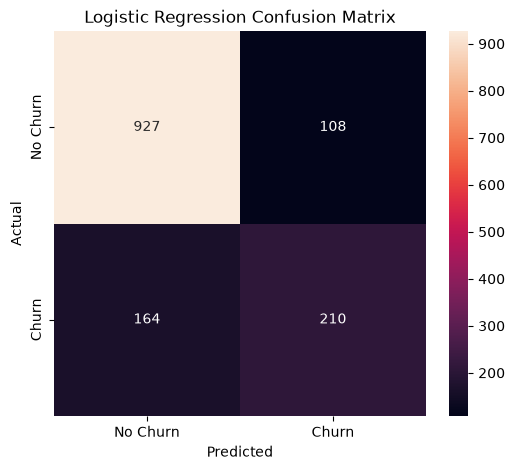

In [24]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8069552874378992,
 'Precision': 0.660377358490566,
 'Recall': 0.5614973262032086,
 'F1': 0.6069364161849711,
 'ROC_AUC': 0.8421710713270816}

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[927 108]
 [164 210]]


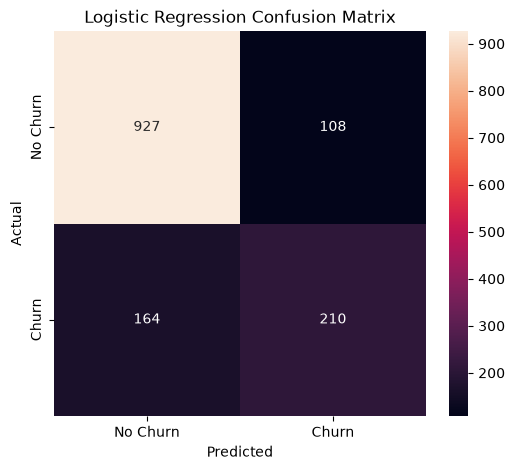

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.8069552874378992
Precision: 0.660377358490566
Recall   : 0.5614973262032086
F1 Score : 0.6069364161849711
ROC-AUC  : 0.8421710713270816

Confusion Matrix:
[[927 108]
 [164 210]]


In [29]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

print(logistic_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8069552874378992, 'Precision': 0.660377358490566, 'Recall': 0.5614973262032086, 'F1': 0.6069364161849711, 'ROC_AUC': 0.8421710713270816}


In [30]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [31]:
y_pred_rf = random_forest_model.predict(X_test_processed)

y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [32]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.7757
Precision: 0.5687
Recall   : 0.6417
F1 Score : 0.6030
ROC-AUC  : 0.8270


In [33]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1": rf_f1,
    "ROC_AUC": rf_roc_auc
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.7757274662881476, 'Precision': 0.5687203791469194, 'Recall': 0.6417112299465241, 'F1': 0.6030150753768844, 'ROC_AUC': 0.8269562634012761}


In [34]:
print(logistic_results)
print(rf_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8069552874378992, 'Precision': 0.660377358490566, 'Recall': 0.5614973262032086, 'F1': 0.6069364161849711, 'ROC_AUC': 0.8421710713270816}
{'Model': 'Random Forest', 'Accuracy': 0.7757274662881476, 'Precision': 0.5687203791469194, 'Recall': 0.6417112299465241, 'F1': 0.6030150753768844, 'ROC_AUC': 0.8269562634012761}


In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [36]:
y_pred_xgb = xgb_model.predict(
    X_test_processed
)

y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost Performance")
print("-------------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Performance
-------------------
Accuracy : 0.7991
Precision: 0.6522
Recall   : 0.5214
F1 Score : 0.5795
ROC-AUC  : 0.8440


In [38]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1": xgb_f1,
    "ROC_AUC": xgb_roc_auc
}

print(xgb_results)

{'Model': 'XGBoost', 'Accuracy': 0.7991483321504613, 'Precision': 0.6521739130434783, 'Recall': 0.5213903743315508, 'F1': 0.5794947994056464, 'ROC_AUC': 0.8440401457025498}


In [39]:
model_comparison = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Random Forest,0.775727,0.568720,0.641711,0.603015,0.826956
2,XGBoost,0.799148,0.652174,0.521390,0.579495,0.844040


In [40]:
model_comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.799148,0.652174,0.521390,0.579495,0.844040
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Random Forest,0.775727,0.568720,0.641711,0.603015,0.826956


In [41]:
import shap

C:\Users\sake yaswanth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [42]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))




Number of processed features: 30


In [43]:
feature_names[:20]

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Male', 'cat__Partner_Yes',
       'cat__Dependents_Yes', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes'],
      dtype=object)

In [44]:
processed_test_values = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

X_test_processed_df = pd.DataFrame(
    processed_test_values,
    columns=feature_names,
    index=X_test.index
)

X_test_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
437,-0.441773,1.608483,1.629976,2.706828,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
2280,2.263606,-0.996684,1.168725,-0.610260,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2235,-0.441773,0.346606,0.445324,0.400116,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4460,-0.441773,-0.589626,0.440347,-0.364451,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3761,-0.441773,1.608483,0.588013,1.588421,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


In [45]:
processed_test_values = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

X_test_processed_df = pd.DataFrame(
    processed_test_values,
    columns=feature_names,
    index=X_test.index
)

X_test_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
437,-0.441773,1.608483,1.629976,2.706828,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
2280,2.263606,-0.996684,1.168725,-0.610260,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2235,-0.441773,0.346606,0.445324,0.400116,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4460,-0.441773,-0.589626,0.440347,-0.364451,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3761,-0.441773,1.608483,0.588013,1.588421,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


In [46]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(
    X_test_processed_df
)

print("SHAP values calculated.")

SHAP values calculated.


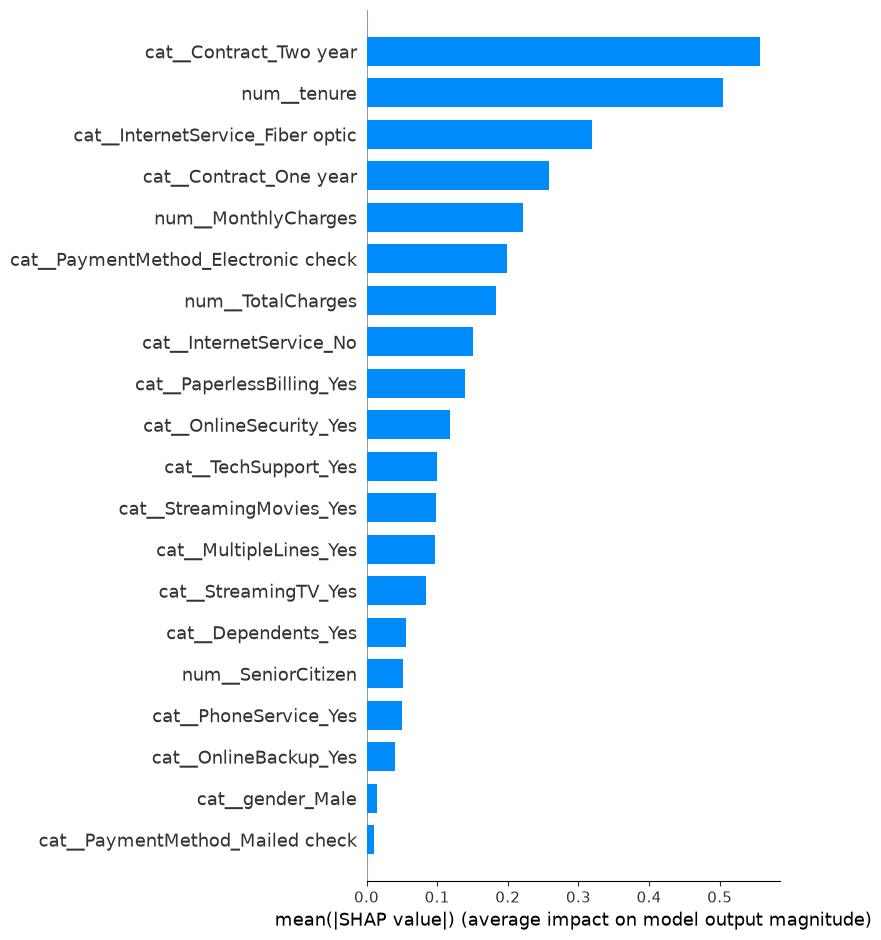

In [47]:
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    plot_type="bar"
)

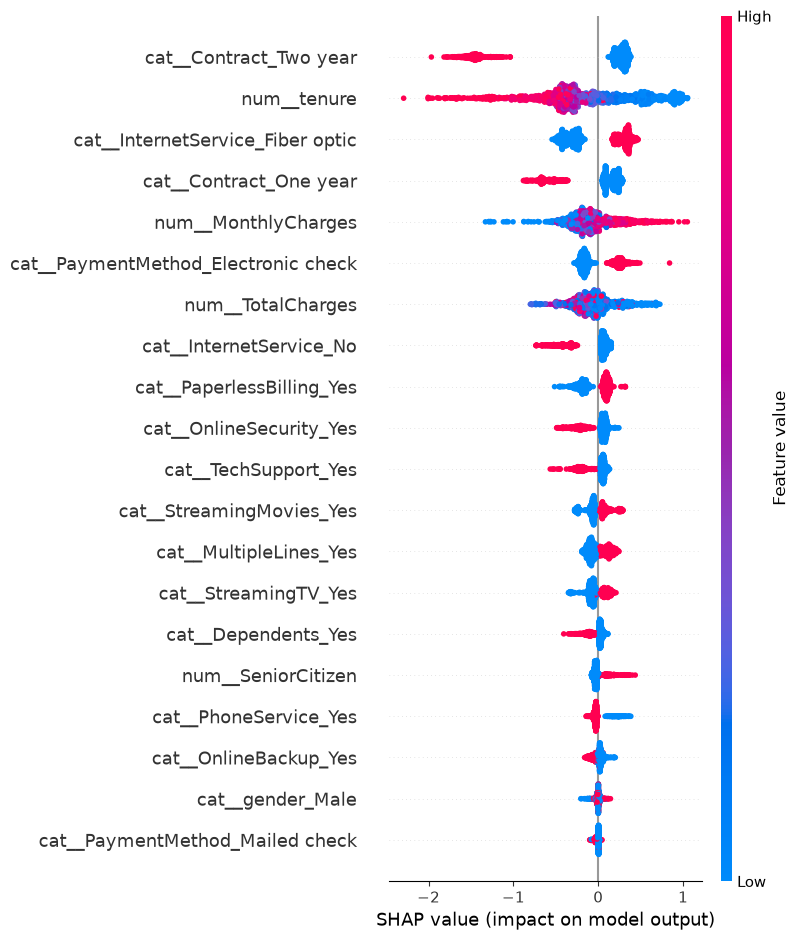

In [48]:
shap.summary_plot(
    shap_values,
    X_test_processed_df
)

## SHAP Explainability Findings

### Main Churn Drivers

The SHAP analysis identifies the following features as the most influential
drivers of the XGBoost churn predictions:

1. [Feature]
2. [Feature]
3. [Feature]
4. [Feature]
5. [Feature]

### Interpretation

[Explain how the most important features influence churn predictions based
on the SHAP summary plot.]

These findings help explain the model's predictions and can later be used
to create customer-risk segments and business recommendations.

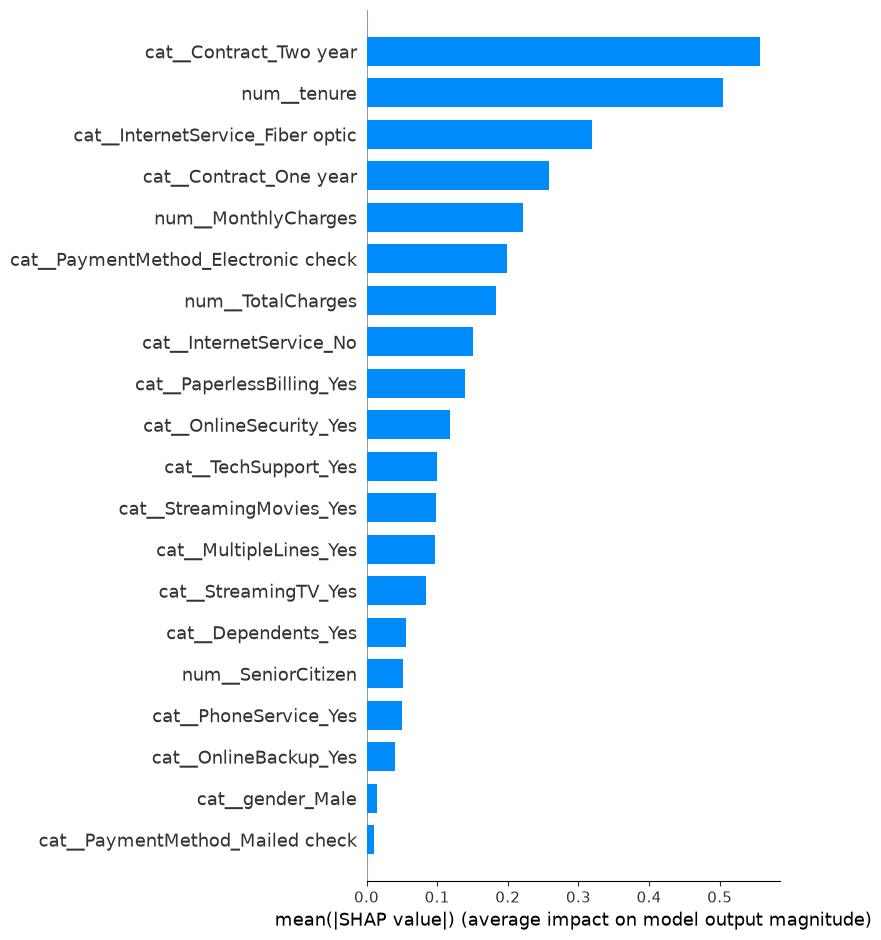

In [49]:
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    plot_type="bar"
)

In [50]:
y_prob_xgb

array([0.01776267, 0.83744144, 0.06002023, ..., 0.09700296, 0.02563993,
       0.00281145], shape=(1409,), dtype=float32)

In [51]:
risk_df = df.loc[X_test.index, [
    "customerID",
    "Contract",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].copy()

risk_df["ChurnProbability"] = y_prob_xgb

risk_df.head()

,customerID,Contract,tenure,MonthlyCharges,TotalCharges,ChurnProbability
437,4376-KFVRS,Two year,72,114.05,8468.20,0.017763
2280,2754-SDJRD,Month-to-month,8,100.15,908.55,0.837441
2235,9917-KWRBE,One year,41,78.35,3211.20,0.060020
4460,0365-GXEZS,Month-to-month,18,78.20,1468.75,0.305603
3761,9385-NXKDA,Two year,72,82.65,5919.35,0.006349


In [52]:
def assign_risk(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"


risk_df["RiskSegment"] = risk_df["ChurnProbability"].apply(
    assign_risk
)

risk_df.head()

,customerID,Contract,tenure,MonthlyCharges,TotalCharges,ChurnProbability,RiskSegment
437,4376-KFVRS,Two year,72,114.05,8468.20,0.017763,Low Risk
2280,2754-SDJRD,Month-to-month,8,100.15,908.55,0.837441,High Risk
2235,9917-KWRBE,One year,41,78.35,3211.20,0.060020,Low Risk
4460,0365-GXEZS,Month-to-month,18,78.20,1468.75,0.305603,Medium Risk
3761,9385-NXKDA,Two year,72,82.65,5919.35,0.006349,Low Risk


In [53]:
risk_counts = risk_df["RiskSegment"].value_counts()

print(risk_counts)


RiskSegment
Low Risk       870
Medium Risk    351
High Risk      188
Name: count, dtype: int64


In [54]:
risk_percentages = (
    risk_df["RiskSegment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(risk_percentages)

RiskSegment
Low Risk       61.75
Medium Risk    24.91
High Risk      13.34
Name: proportion, dtype: float64


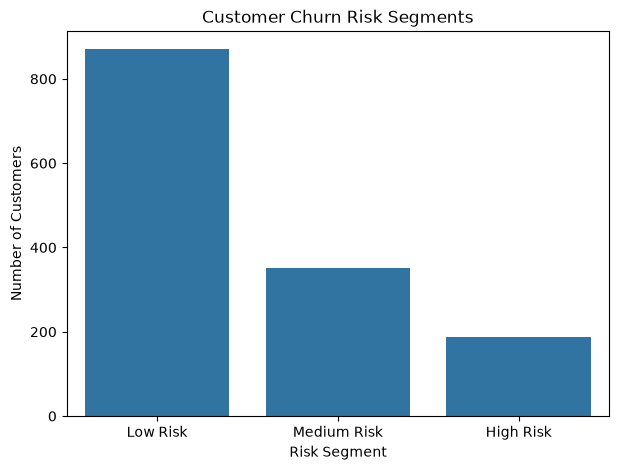

In [55]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=risk_df,
    x="RiskSegment",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Customer Churn Risk Segments")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")

plt.show()

In [56]:
high_risk = risk_df[
    risk_df["RiskSegment"] == "High Risk"
].copy()

high_risk.head(20)

,customerID,Contract,tenure,MonthlyCharges,TotalCharges,ChurnProbability,RiskSegment
2280,2754-SDJRD,Month-to-month,8,100.15,908.55,0.837441,High Risk
5748,4686-UXDML,Month-to-month,21,99.85,1992.55,0.611410,High Risk
3524,4706-AXVKM,Month-to-month,11,84.80,906.85,0.748316,High Risk
2136,1379-FRVEB,Month-to-month,15,91.00,1430.05,0.620698,High Risk
6529,7235-NXZCP,Month-to-month,2,74.85,156.40,0.704410,High Risk
6125,0871-URUWO,Month-to-month,13,102.25,1359.00,0.676733,High Risk
5547,9611-CTWIH,Month-to-month,3,89.45,240.45,0.729660,High Risk
346,2034-GDRCN,Month-to-month,2,90.40,168.20,0.754409,High Risk
6633,4415-IJZTP,Month-to-month,1,74.50,74.50,0.858962,High Risk
2519,4927-WWOOZ,Month-to-month,2,91.45,171.45,0.837220,High Risk


In [57]:
print("High-risk customers:", len(high_risk))


High-risk customers: 188


In [58]:
high_risk[[
    "Contract",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnProbability"
]].describe(include="all")

,Contract,tenure,MonthlyCharges,TotalCharges,ChurnProbability
count,188,188.00000,188.000000,188.000000,188.000000
unique,2,NaN,NaN,NaN,NaN
top,Month-to-month,NaN,NaN,NaN,NaN
freq,187,NaN,NaN,NaN,NaN
mean,NaN,6.12766,79.331383,545.087500,0.745501
std,NaN,7.48222,17.875961,731.347026,0.090022
min,NaN,1.00000,24.800000,24.800000,0.600582
25%,NaN,1.00000,73.887500,79.300000,0.665939
50%,NaN,3.00000,79.950000,250.350000,0.737874
75%,NaN,8.00000,93.500000,704.225000,0.828078


In [59]:
high_risk["Contract"].value_counts()

Contract
Month-to-month    187
One year            1
Name: count, dtype: int64

## Customer Risk Segmentation

Customers were segmented using the XGBoost predicted probability of churn.

### Risk Categories

- Low Risk: churn probability below 30%
- Medium Risk: churn probability from 30% to below 60%
- High Risk: churn probability of 60% or above

### Business Interpretation

High-risk customers represent customers who may require proactive
retention attention. Their characteristics can be analyzed to identify
common churn patterns and support targeted retention strategies.

The risk scores can later be exposed through the API/dashboard so that
business users can identify customers requiring attention.

In [60]:
customer_risk_output = risk_df[[
    "customerID",
    "ChurnProbability",
    "RiskSegment",
    "Contract",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].copy()

customer_risk_output["ChurnProbability"] = (
    customer_risk_output["ChurnProbability"] * 100
).round(2)

customer_risk_output.head(10)

,customerID,ChurnProbability,RiskSegment,Contract,tenure,MonthlyCharges,TotalCharges
437,4376-KFVRS,1.780000,Low Risk,Two year,72,114.05,8468.20
2280,2754-SDJRD,83.739998,High Risk,Month-to-month,8,100.15,908.55
2235,9917-KWRBE,6.000000,Low Risk,One year,41,78.35,3211.20
4460,0365-GXEZS,30.559999,Medium Risk,Month-to-month,18,78.20,1468.75
3761,9385-NXKDA,0.630000,Low Risk,Two year,72,82.65,5919.35
5748,4686-UXDML,61.139999,High Risk,Month-to-month,21,99.85,1992.55
3568,2227-JRSJX,44.400002,Medium Risk,Month-to-month,21,99.15,1956.40
2976,4830-FAXFM,11.570000,Low Risk,Month-to-month,19,24.10,439.20
5928,1830-IPXVJ,0.920000,Low Risk,Two year,61,19.75,1311.60
1639,4690-LLKUA,34.709999,Medium Risk,Month-to-month,17,45.05,770.60


In [61]:
customer_risk_output = risk_df[[
    "customerID",
    "ChurnProbability",
    "RiskSegment",
    "Contract",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].copy()

customer_risk_output["ChurnProbability"] = (
    customer_risk_output["ChurnProbability"] * 100
).round(2)

customer_risk_output.head(10)

,customerID,ChurnProbability,RiskSegment,Contract,tenure,MonthlyCharges,TotalCharges
437,4376-KFVRS,1.780000,Low Risk,Two year,72,114.05,8468.20
2280,2754-SDJRD,83.739998,High Risk,Month-to-month,8,100.15,908.55
2235,9917-KWRBE,6.000000,Low Risk,One year,41,78.35,3211.20
4460,0365-GXEZS,30.559999,Medium Risk,Month-to-month,18,78.20,1468.75
3761,9385-NXKDA,0.630000,Low Risk,Two year,72,82.65,5919.35
5748,4686-UXDML,61.139999,High Risk,Month-to-month,21,99.85,1992.55
3568,2227-JRSJX,44.400002,Medium Risk,Month-to-month,21,99.15,1956.40
2976,4830-FAXFM,11.570000,Low Risk,Month-to-month,19,24.10,439.20
5928,1830-IPXVJ,0.920000,Low Risk,Two year,61,19.75,1311.60
1639,4690-LLKUA,34.709999,Medium Risk,Month-to-month,17,45.05,770.60


In [62]:
import os

os.makedirs("../data/processed", exist_ok=True)

customer_risk_output.to_csv(
    "../data/processed/customer_risk_segments.csv",
    index=False
)

print("Customer risk segments saved successfully.")

Customer risk segments saved successfully.


In [64]:
risk_check = pd.read_csv(
    "../data/processed/customer_risk_segments.csv"
)

print(risk_check.shape)
risk_check.head()

(1409, 7)


,customerID,ChurnProbability,RiskSegment,Contract,tenure,MonthlyCharges,TotalCharges
0,4376-KFVRS,1.78,Low Risk,Two year,72,114.05,8468.20
1,2754-SDJRD,83.74,High Risk,Month-to-month,8,100.15,908.55
2,9917-KWRBE,6.00,Low Risk,One year,41,78.35,3211.20
3,0365-GXEZS,30.56,Medium Risk,Month-to-month,18,78.20,1468.75
4,9385-NXKDA,0.63,Low Risk,Two year,72,82.65,5919.35


In [65]:
final_model_comparison = model_comparison.copy()

final_model_comparison = final_model_comparison.round(4)

final_model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8070,0.6604,0.5615,0.6069,0.8422
1,Random Forest,0.7757,0.5687,0.6417,0.6030,0.8270
2,XGBoost,0.7991,0.6522,0.5214,0.5795,0.8440


In [66]:
import os

os.makedirs("../data/processed", exist_ok=True)

final_model_comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [67]:
total_customers = len(df)

churned_customers = (df["Churn"] == "Yes").sum()

overall_churn_rate = (
    churned_customers / total_customers
) * 100

analytics_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate",
        "High Risk Customers",
        "Medium Risk Customers",
        "Low Risk Customers"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(overall_churn_rate, 2),
        (risk_df["RiskSegment"] == "High Risk").sum(),
        (risk_df["RiskSegment"] == "Medium Risk").sum(),
        (risk_df["RiskSegment"] == "Low Risk").sum()
    ]
})

analytics_summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Overall Churn Rate,26.54
3,High Risk Customers,188.00
4,Medium Risk Customers,351.00
5,Low Risk Customers,870.00


In [ ]:
analytics_summary.to_csv(
    "../data/processed/churn_analytics_summary.csv",
    index=False
)

print("Analytics summary saved successfully.")

Analytics summary saved successfully.


In [70]:
risk_output = pd.read_csv(
    "../data/processed/customer_risk_segments.csv"
)

print(risk_output.shape)
print(risk_output.head())

(1409, 7)
   customerID  ChurnProbability  RiskSegment        Contract  tenure  \
0  4376-KFVRS              1.78     Low Risk        Two year      72   
1  2754-SDJRD             83.74    High Risk  Month-to-month       8   
2  9917-KWRBE              6.00     Low Risk        One year      41   
3  0365-GXEZS             30.56  Medium Risk  Month-to-month      18   
4  9385-NXKDA              0.63     Low Risk        Two year      72   

   MonthlyCharges  TotalCharges  
0          114.05       8468.20  
1          100.15        908.55  
2           78.35       3211.20  
3           78.20       1468.75  
4           82.65       5919.35  
